#### static v dynamic prompting

##### prompt template 
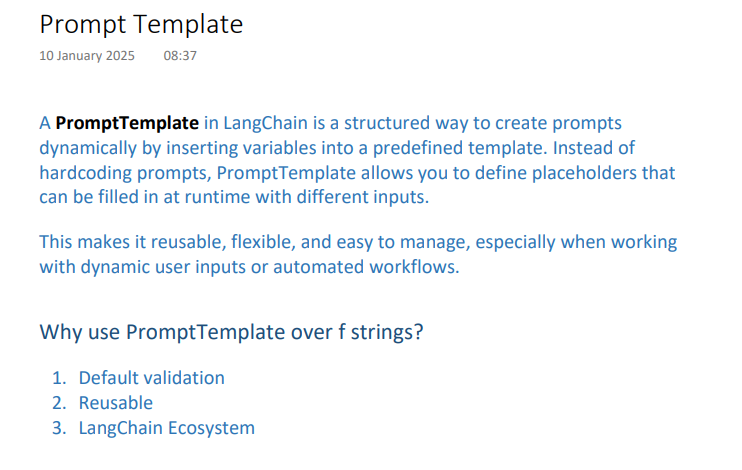


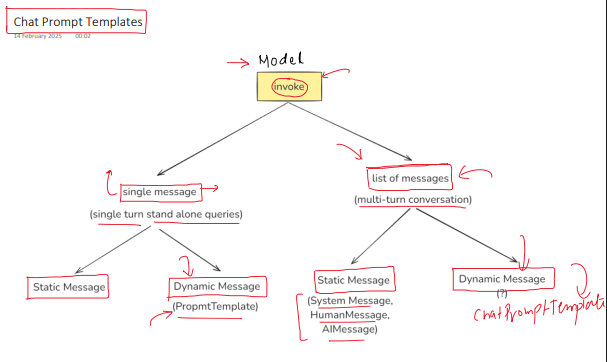

#### CHATBOT(types of mssges)
### list of messages(full convo) but static message

In [1]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model="openai/gpt-oss-120b")

chat_history = [
    SystemMessage(content='You are a helpful AI assistant')
]

while True:
    user_input = input('You: ')
    chat_history.append(HumanMessage(content=user_input))
    if user_input == 'exit':
        break
    result = model.invoke(chat_history)
    chat_history.append(AIMessage(content=result.content))
    print("AI: ",result.content)

print(chat_history)

AI:  Hello! How can I assist you today?
AI:  A Transformer replaces recurrence and convolution with only self‑attention layers, showing that pure attention mechanisms can effectively model sequential data.
[SystemMessage(content='You are a helpful AI assistant', additional_kwargs={}, response_metadata={}), HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='explain attention is all you nedd in 1 line ', additional_kwargs={}, response_metadata={}), AIMessage(content='A Transformer replaces recurrence and convolution with only self‑attention layers, showing that pure attention mechanisms can effectively model sequential data.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='exit', additional_kwargs={}, response_metadata={})]


##### list of mssg ===> dynamic msssg using chatprompttemplate

In [2]:
from langchain_core.prompts import ChatPromptTemplate

chat_template = ChatPromptTemplate([
    ('system', 'You are a helpful {domain} expert'),
    ('human', 'Explain in simple terms, what is {topic}')
])

prompt = chat_template.invoke({'domain':'cricket','topic':'Dusra'})

print(prompt)

messages=[SystemMessage(content='You are a helpful cricket expert', additional_kwargs={}, response_metadata={}), HumanMessage(content='Explain in simple terms, what is Dusra', additional_kwargs={}, response_metadata={})]


### Message placeholder
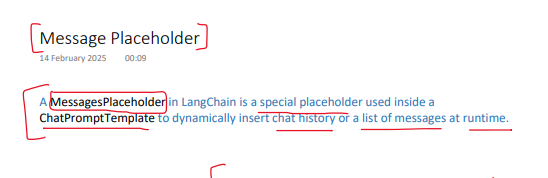

In [3]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
# chat template
chat_template = ChatPromptTemplate([
    ('system','You are a helpful customer support agent'),
    MessagesPlaceholder(variable_name='chat_history'),
    ('human','{query}')
])

chat_history = []
# load chat history
with open('chathistory.txt') as f:
    chat_history.extend(f.readlines())

print(chat_history)

# create prompt
prompt = chat_template.invoke({'chat_history':chat_history, 'query':'Where is my refund'})

print(prompt)

['HumanMessage(content="I want to request a refund for my order #12345.")\n', 'AIMessage(content="Your refund request for order #12345 has been initiated. It will be processed in 3-5 business days.")']
messages=[SystemMessage(content='You are a helpful customer support agent', additional_kwargs={}, response_metadata={}), HumanMessage(content='HumanMessage(content="I want to request a refund for my order #12345.")\n', additional_kwargs={}, response_metadata={}), HumanMessage(content='AIMessage(content="Your refund request for order #12345 has been initiated. It will be processed in 3-5 business days.")', additional_kwargs={}, response_metadata={}), HumanMessage(content='Where is my refund', additional_kwargs={}, response_metadata={})]
